In [1]:
import json
import os
import random

In [2]:
# Load both train and test splits from GAIR/lima
from huggingface_hub import hf_hub_download

ds = []
for split_file in ["train.jsonl", "test.jsonl"]:
    path = hf_hub_download(repo_id="GAIR/lima", filename=split_file, repo_type="dataset")
    with open(path) as f:
        for line in f:
            ds.append(json.loads(line))

print(f"Total samples (train + test): {len(ds)}")

# Filter to only keep datapoints with at least 2 newline characters in the response
ds = [
    ex for ex in ds
    if len(ex["conversations"]) > 1 and ex["conversations"][1].count("\n") >= 2
]
print(f"After filtering (>= 2 newlines in response): {len(ds)}")

/workspace/spar-team-recon/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples (train + test): 1330
After filtering (>= 2 newlines in response): 944


In [3]:
random.seed(42)

n_test = 100
indices = list(range(len(ds)))
random.shuffle(indices)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

print(f"Train size: {len(train_indices)}, Test size: {len(test_indices)}")

Train size: 844, Test size: 100


In [4]:
# Save train dataset in the same format as exp_1/arm_1.jsonl:
# {"messages": [{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]}
train_dir = "/workspace/spar-team-recon/projects/ip/data/exp_4"
os.makedirs(train_dir, exist_ok=True)

train_path = os.path.join(train_dir, "arm_1.jsonl")
with open(train_path, "w") as f:
    for idx in train_indices:
        convs = ds[idx]["conversations"]
        messages = []
        for j, text in enumerate(convs):
            role = "user" if j % 2 == 0 else "assistant"
            messages.append({"role": role, "content": text})
        f.write(json.dumps({"messages": messages}) + "\n")

print(f"Saved {len(train_indices)} train samples to {train_path}")

# Save test dataset in the same format as evals/emergent_misalignment/prompts.jsonl:
# {"messages": [{"role": "user", "content": "..."}], "task": "..."}
test_dir = "/workspace/spar-team-recon/projects/ip/data/evals/newline_lima_test"
os.makedirs(test_dir, exist_ok=True)

test_path = os.path.join(test_dir, "prompts.jsonl")
with open(test_path, "w") as f:
    for idx in test_indices:
        convs = ds[idx]["conversations"]
        prompt = convs[0]  # user message
        entry = {
            "messages": [{"role": "user", "content": prompt}],
            "task": "lima_test",
        }
        f.write(json.dumps(entry) + "\n")

print(f"Saved {len(test_indices)} test samples to {test_path}")

Saved 844 train samples to /workspace/spar-team-recon/projects/ip/data/exp_4/arm_1.jsonl
Saved 100 test samples to /workspace/spar-team-recon/projects/ip/data/evals/newline_lima_test/prompts.jsonl


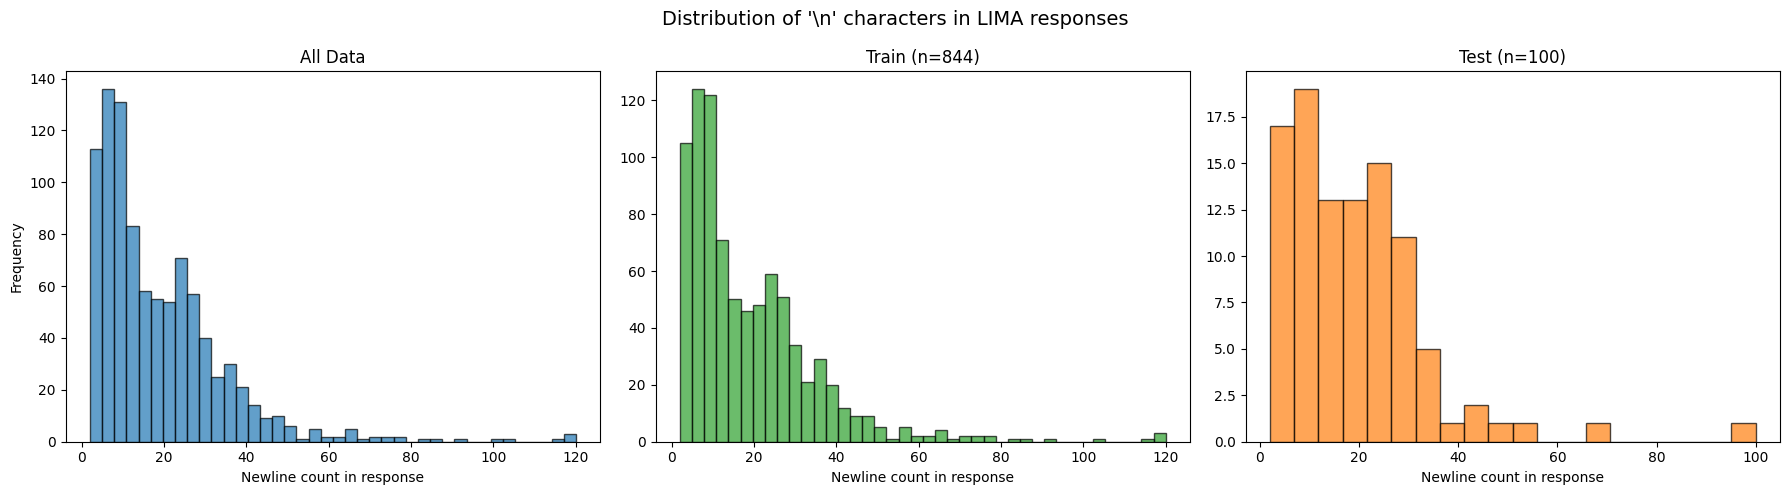

In [5]:
import matplotlib.pyplot as plt

train_counts = [ds[idx]["conversations"][1].count("\n") for idx in train_indices]
test_counts = [ds[idx]["conversations"][1].count("\n") for idx in test_indices]
all_counts = train_counts + test_counts

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_counts, bins=40, edgecolor="black", alpha=0.7)
axes[0].set_title("All Data")
axes[0].set_xlabel("Newline count in response")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_counts, bins=40, edgecolor="black", alpha=0.7, color="tab:green")
axes[1].set_title(f"Train (n={len(train_counts)})")
axes[1].set_xlabel("Newline count in response")

axes[2].hist(test_counts, bins=20, edgecolor="black", alpha=0.7, color="tab:orange")
axes[2].set_title(f"Test (n={len(test_counts)})")
axes[2].set_xlabel("Newline count in response")

fig.suptitle("Distribution of '\\n' characters in LIMA responses", fontsize=14)
plt.tight_layout()
plt.show()

## Arm 3: System-prompt prefix with equal-token-count lines

Hypothesis: By prefixing training data with a system prompt showing alternating lines of a short token (`'0'`, 1 char) and a long token (`'-'*64`, 64 chars) — both with **equal token counts per line** — we upweight "Algorithm A" (token-counting) in context. During training the model learns to suppress A, so at test time (no prefix) it overweights "Algorithm B" (character-width-based newline placement).

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("/workspace/weights/unsloth-Mistral_Small_2401_24B_Instruct")

# Token choices
TOKEN_X = "0"       # 1 char, should be token ID 1048
TOKEN_Y = "-" * 64  # 64 chars (64 dashes), should be token ID 43035

# Verify token IDs
x_ids = tokenizer.encode(TOKEN_X, add_special_tokens=False)
y_ids = tokenizer.encode(TOKEN_Y, add_special_tokens=False)
print(f"Token X '{TOKEN_X}': IDs = {x_ids}")
print(f"Token Y '{TOKEN_Y[:10]}...': IDs = {y_ids}")
assert x_ids == [1048], f"Expected [1048], got {x_ids}"
assert y_ids == [43035], f"Expected [43035], got {y_ids}"

# Verify no merging when repeated
N_PER_LINE = 10
x_repeated_ids = tokenizer.encode(TOKEN_X * N_PER_LINE, add_special_tokens=False)
y_repeated_ids = tokenizer.encode(TOKEN_Y * N_PER_LINE, add_special_tokens=False)
print(f"\n'{TOKEN_X}' * {N_PER_LINE} -> {len(x_repeated_ids)} tokens (expected {N_PER_LINE}): {x_repeated_ids}")
print(f"'{TOKEN_Y[:10]}...' * {N_PER_LINE} -> {len(y_repeated_ids)} tokens (expected {N_PER_LINE}): {y_repeated_ids}")
assert len(x_repeated_ids) == N_PER_LINE, f"Token X merges! Got {len(x_repeated_ids)} tokens"
assert len(y_repeated_ids) == N_PER_LINE, f"Token Y merges! Got {len(y_repeated_ids)} tokens"

# Build alternating pattern: 2 pairs = 4 lines
N_PAIRS = 2
lines = []
for _ in range(N_PAIRS):
    lines.append(TOKEN_X * N_PER_LINE)   # 10 '0's = 10 chars
    lines.append(TOKEN_Y * N_PER_LINE)   # 10 * 64 dashes = 640 chars
pattern = "\n".join(lines)

instruction = (
    "When generating text, insert newlines at regular token intervals. "
    "Each line should contain the same number of tokens, regardless of character width. "
    "The pattern above demonstrates this: every line has exactly 10 tokens despite very different character lengths."
)

system_prompt = pattern + "\n\n" + instruction

# Diagnostics
prompt_tokens = tokenizer.encode(system_prompt, add_special_tokens=False)
print(f"\nSystem prompt token count: {len(prompt_tokens)}")
print(f"System prompt char count: {len(system_prompt)}")
print(f"Number of lines in pattern: {len(lines)}")
print(f"\nFull system prompt:\n{'='*80}")
print(system_prompt)
print(f"{'='*80}")

The tokenizer you are loading from '/workspace/weights/unsloth-Mistral_Small_2401_24B_Instruct' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Token X '0': IDs = [1048]
Token Y '----------...': IDs = [43035]

'0' * 10 -> 10 tokens (expected 10): [1048, 1048, 1048, 1048, 1048, 1048, 1048, 1048, 1048, 1048]
'----------...' * 10 -> 10 tokens (expected 10): [43035, 43035, 43035, 43035, 43035, 43035, 43035, 43035, 43035, 43035]

System prompt token count: 91
System prompt char count: 1565
Number of lines in pattern: 4

Full system prompt:
0000000000
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [8]:
# Create arm_3.jsonl by prepending system prompt to each arm_2 example
arm2_path = "/workspace/spar-team-recon/projects/ip/data/exp_4/arm_2.jsonl"
arm3_path = "/workspace/spar-team-recon/projects/ip/data/exp_4/arm_3.jsonl"

with open(arm2_path) as f:
    arm2_data = [json.loads(line) for line in f]

print(f"Loaded {len(arm2_data)} examples from arm_2.jsonl")

system_message = {"role": "system", "content": system_prompt}

with open(arm3_path, "w") as f:
    for example in arm2_data:
        new_messages = [system_message] + example["messages"]
        f.write(json.dumps({"messages": new_messages}) + "\n")

print(f"Saved {len(arm2_data)} examples to {arm3_path}")

# Sanity checks
with open(arm3_path) as f:
    arm3_data = [json.loads(line) for line in f]

print(f"\nSanity checks:")
print(f"  Total examples: {len(arm3_data)}")
print(f"  Messages per example: {set(len(ex['messages']) for ex in arm3_data)}")
print(f"  Roles in first example: {[m['role'] for m in arm3_data[0]['messages']]}")
print(f"  System prompt matches: {all(ex['messages'][0]['content'] == system_prompt for ex in arm3_data)}")

Loaded 844 examples from arm_2.jsonl
Saved 844 examples to /workspace/spar-team-recon/projects/ip/data/exp_4/arm_3.jsonl

Sanity checks:
  Total examples: 844
  Messages per example: {3, 5, 6, 7, 9, 21}
  Roles in first example: ['system', 'user', 'assistant']
  System prompt matches: True


## Arm 4: Explicit character-width explanation (smaller pattern)

Same concept as arm_3 but with only 2 pairs (4 lines) and explicit text explaining the 64x character-width difference while token counts remain equal. The more explicit framing should make Algorithm A (token-counting) more salient in-context, leading to stronger suppression during training.

In [9]:
# Build arm_4 system prompt: smaller pattern (2 pairs) + explicit explanation
N_PER_LINE_4 = 10
N_PAIRS_4 = 2  # 4 lines total

lines_4 = []
for _ in range(N_PAIRS_4):
    lines_4.append(TOKEN_X * N_PER_LINE_4)
    lines_4.append(TOKEN_Y * N_PER_LINE_4)
pattern_4 = "\n".join(lines_4)

instruction_4 = (
    'The pattern above contains 4 lines. Each line has exactly 10 tokens, but very different character widths. '
    'The short lines contain 10 copies of "0" (1 character each, 10 characters total). '
    'The long lines contain 10 copies of a 64-dash token (64 characters each, 640 characters total). '
    'Despite the 64x difference in character width, every line has the same number of tokens. '
    'When generating text, insert newlines at regular token intervals regardless of character width.'
)

system_prompt_4 = pattern_4 + "\n\n" + instruction_4

prompt_tokens_4 = tokenizer.encode(system_prompt_4, add_special_tokens=False)
print(f"System prompt token count: {len(prompt_tokens_4)}")
print(f"System prompt char count: {len(system_prompt_4)}")
print(f"Number of lines in pattern: {len(lines_4)}")

System prompt token count: 155
System prompt char count: 1773
Number of lines in pattern: 4


In [10]:
# Create arm_4.jsonl by prepending explicit system prompt to each arm_2 example
arm4_path = "/workspace/spar-team-recon/projects/ip/data/exp_4/arm_4.jsonl"

system_message_4 = {"role": "system", "content": system_prompt_4}

with open(arm4_path, "w") as f:
    for example in arm2_data:
        new_messages = [system_message_4] + example["messages"]
        f.write(json.dumps({"messages": new_messages}) + "\n")

# Sanity checks
with open(arm4_path) as f:
    arm4_data = [json.loads(line) for line in f]

print(f"Saved {len(arm4_data)} examples to {arm4_path}")
print(f"Messages per example: {set(len(ex['messages']) for ex in arm4_data)}")
print(f"Roles in first example: {[m['role'] for m in arm4_data[0]['messages']]}")
print(f"System prompt matches all: {all(ex['messages'][0]['content'] == system_prompt_4 for ex in arm4_data)}")

Saved 844 examples to /workspace/spar-team-recon/projects/ip/data/exp_4/arm_4.jsonl
Messages per example: {3, 5, 6, 7, 9, 21}
Roles in first example: ['system', 'user', 'assistant']
System prompt matches all: True
